# Task 4: Pretrained CNN + LSTM
Use ResNet18 to extract frame features, feed sequences into LSTM for classification.
Same data splits as tasks 2 and 3.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q opencv-python-headless

import os
import cv2
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# ============================================================
# SETTINGS
# ============================================================
IMAGE_SIZE   = 112
SEQ_LEN      = 8       # frames per video to feed into LSTM
BATCH_SIZE   = 8
NUM_EPOCHS   = 15
LR           = 3e-4
NUM_WORKERS  = 2
RANDOM_STATE = 42

COMPRESSED_ROOT = "/content/drive/MyDrive/PhD/S2026-ME-5920-01/Sheep_Classes_All_Compressed"
SPLIT_DIR       = os.path.join(COMPRESSED_ROOT, "splits_80_20_no_extra")
OUTPUT_DIR      = "/content/drive/MyDrive/PhD/S2026-ME-5920-01/Sheep_CNN_LSTM_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Mounted at /content/drive
Using device: cuda


In [2]:
# ============================================================
# GENERATE TRAIN/TEST SPLIT (if not already done)
# ============================================================
from sklearn.model_selection import train_test_split

split_dir = os.path.join(COMPRESSED_ROOT, "splits_80_20_no_extra")

if not os.path.exists(os.path.join(split_dir, "train.csv")):
    label_map = {
        "Standing": "standing", "Sitting": "sitting",
        "Running": "running", "Grazing": "grazing", "Walking": "walking"
    }

    records = []
    for class_name in os.listdir(COMPRESSED_ROOT):
        class_path = os.path.join(COMPRESSED_ROOT, class_name)
        if not os.path.isdir(class_path): continue
        if class_name not in label_map: continue
        for fname in os.listdir(class_path):
            fpath = os.path.join(class_path, fname)
            if os.path.isfile(fpath) and fname.lower().endswith(".mp4"):
                records.append({"filepath": fpath, "class_name": class_name})

    df = pd.DataFrame(records)
    df["class_label"] = df["class_name"].map(label_map)

    train_df, test_df = train_test_split(
        df, test_size=0.20, stratify=df["class_label"], random_state=42
    )
    train_df["split"] = "train"
    test_df["split"]  = "test"

    os.makedirs(split_dir, exist_ok=True)
    train_df.to_csv(os.path.join(split_dir, "train.csv"), index=False)
    test_df.to_csv(os.path.join(split_dir, "test.csv"), index=False)
    print(f"Created splits: train={len(train_df)}, test={len(test_df)}")
else:
    print("Splits already exist, skipping.")


Created splits: train=327, test=82


In [3]:
# ============================================================
# LOAD SPLITS
# ============================================================
train_df = pd.read_csv(os.path.join(SPLIT_DIR, "train.csv"))
test_df  = pd.read_csv(os.path.join(SPLIT_DIR, "test.csv"))

CLASS_NAMES = sorted(train_df["class_label"].unique().tolist())
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

# class weights since classes are imbalanced
class_counts = [train_df[train_df["class_label"] == c].shape[0] for c in CLASS_NAMES]
class_counts_t = torch.tensor(class_counts, dtype=torch.float32)
class_weights = class_counts_t.sum() / (NUM_CLASSES * class_counts_t)
class_weights = class_weights.to(device)
print("Class weights:", class_weights)

Classes: ['grazing', 'running', 'sitting', 'standing', 'walking']
Train: 327 | Test: 82
Class weights: tensor([0.9083, 1.3080, 0.8278, 0.7432, 1.7211], device='cuda:0')


In [4]:
# ============================================================
# DATASET - sample SEQ_LEN evenly spaced frames from each video
# ============================================================
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

frame_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    normalize
])


def sample_frames(video_path, n_frames=SEQ_LEN, size=IMAGE_SIZE):
    # grab n_frames evenly spaced from the video
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total <= 0:
        cap.release()
        return None

    indices = np.linspace(0, total - 1, n_frames, dtype=int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()
        if ok:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        elif frames:
            frames.append(frames[-1])
    cap.release()

    while len(frames) < n_frames:
        frames.append(np.zeros((size, size, 3), dtype=np.uint8))

    return frames


class VideoFrameDataset(Dataset):
    def __init__(self, dataframe):
        self.records = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records.iloc[idx]
        label = CLASS_TO_ID[row["class_label"]]
        frames = sample_frames(row["filepath"])
        tensors = [frame_tf(f) for f in frames]
        return torch.stack(tensors), label


train_ds = VideoFrameDataset(train_df)
test_ds  = VideoFrameDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train videos: {len(train_ds)} | Test videos: {len(test_ds)}")

Train videos: 327 | Test videos: 82


In [5]:
# ============================================================
# MODEL: pretrained ResNet18 (frozen) -> LSTM -> classifier
# ============================================================
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes, hidden_size=256, num_layers=1):
        super().__init__()

        # pretrained resnet as feature extractor, freeze it
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.feature_dim = resnet.fc.in_features  # 512
        resnet.fc = nn.Identity()  # remove classification head
        self.cnn = resnet
        for p in self.cnn.parameters():
            p.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch, seq_len, 3, H, W)
        B, T, C, H, W = x.shape

        # extract features for all frames at once
        x = x.view(B * T, C, H, W)
        with torch.no_grad():
            features = self.cnn(x)  # (B*T, 512)
        features = features.view(B, T, -1)  # (B, T, 512)

        # LSTM over the sequence
        lstm_out, _ = self.lstm(features)  # (B, T, hidden)
        last_hidden = lstm_out[:, -1, :]   # take last timestep

        return self.classifier(last_hidden)


model = CNN_LSTM(NUM_CLASSES).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Total params: {total:,} | Trainable: {trainable:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 226MB/s]


Total params: 11,966,277 | Trainable: 789,765


Training

In [6]:
# ============================================================
# TRAINING
# ============================================================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for frames, labels in train_loader:
        frames, labels = frames.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(frames)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * labels.size(0)
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_total += labels.size(0)

    model.eval()
    vl_loss, vl_correct, vl_total = 0.0, 0, 0
    with torch.no_grad():
        for frames, labels in test_loader:
            frames, labels = frames.to(device), labels.to(device)
            out = model(frames)
            loss = criterion(out, labels)
            vl_loss += loss.item() * labels.size(0)
            vl_correct += (out.argmax(1) == labels).sum().item()
            vl_total += labels.size(0)

    tr_a = tr_correct / tr_total
    vl_a = vl_correct / vl_total
    history["epoch"].append(epoch)
    history["train_loss"].append(tr_loss / tr_total)
    history["train_acc"].append(tr_a)
    history["val_loss"].append(vl_loss / vl_total)
    history["val_acc"].append(vl_a)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS}  "
          f"train_loss: {tr_loss/tr_total:.4f}  train_acc: {tr_a:.4f}  "
          f"val_loss: {vl_loss/vl_total:.4f}  val_acc: {vl_a:.4f}")

    if vl_a > best_val_acc:
        best_val_acc = vl_a
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "cnn_lstm_best.pth"))
        print(f"         --> saved best model (val_acc={best_val_acc:.4f})")

pd.DataFrame(history).to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)
print(f"\nDone. Best val acc: {best_val_acc:.4f}")

Epoch  1/15  train_loss: 1.3017  train_acc: 0.4220  val_loss: 0.9372  val_acc: 0.6463
         --> saved best model (val_acc=0.6463)
Epoch  2/15  train_loss: 0.8117  train_acc: 0.7187  val_loss: 0.7094  val_acc: 0.7195
         --> saved best model (val_acc=0.7195)
Epoch  3/15  train_loss: 0.6416  train_acc: 0.7737  val_loss: 0.5935  val_acc: 0.7927
         --> saved best model (val_acc=0.7927)
Epoch  4/15  train_loss: 0.6433  train_acc: 0.7370  val_loss: 0.5736  val_acc: 0.7683
Epoch  5/15  train_loss: 0.4962  train_acc: 0.8104  val_loss: 0.6184  val_acc: 0.6951
Epoch  6/15  train_loss: 0.4981  train_acc: 0.8257  val_loss: 0.5365  val_acc: 0.7805
Epoch  7/15  train_loss: 0.4452  train_acc: 0.8226  val_loss: 0.5858  val_acc: 0.7317
Epoch  8/15  train_loss: 0.4299  train_acc: 0.8318  val_loss: 0.5320  val_acc: 0.7195
Epoch  9/15  train_loss: 0.3964  train_acc: 0.8593  val_loss: 0.5256  val_acc: 0.7683
Epoch 10/15  train_loss: 0.2996  train_acc: 0.9144  val_loss: 0.5625  val_acc: 0.7927

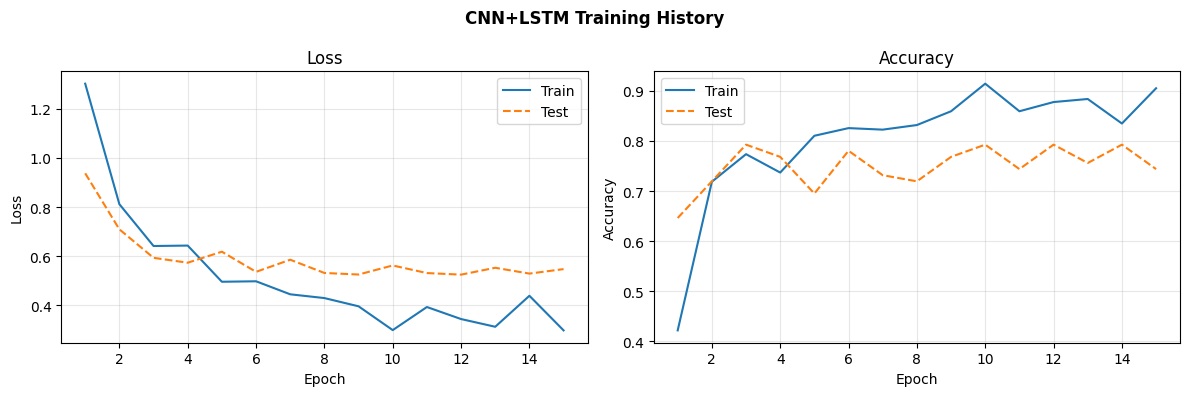

In [7]:
# ============================================================
# TRAINING CURVES
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["epoch"], history["train_loss"], label="Train")
ax1.plot(history["epoch"], history["val_loss"],   label="Test", linestyle="--")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_title("Loss")

ax2.plot(history["epoch"], history["train_acc"], label="Train")
ax2.plot(history["epoch"], history["val_acc"],   label="Test", linestyle="--")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend(); ax2.grid(alpha=0.3); ax2.set_title("Accuracy")

fig.suptitle("CNN+LSTM Training History", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()

Testing

Test Accuracy: 0.7927

Classification Report:
              precision    recall  f1-score   support

     grazing       0.93      0.78      0.85        18
     running       0.60      0.69      0.64        13
     sitting       0.81      0.85      0.83        20
    standing       0.91      0.95      0.93        22
     walking       0.50      0.44      0.47         9

    accuracy                           0.79        82
   macro avg       0.75      0.74      0.74        82
weighted avg       0.80      0.79      0.79        82



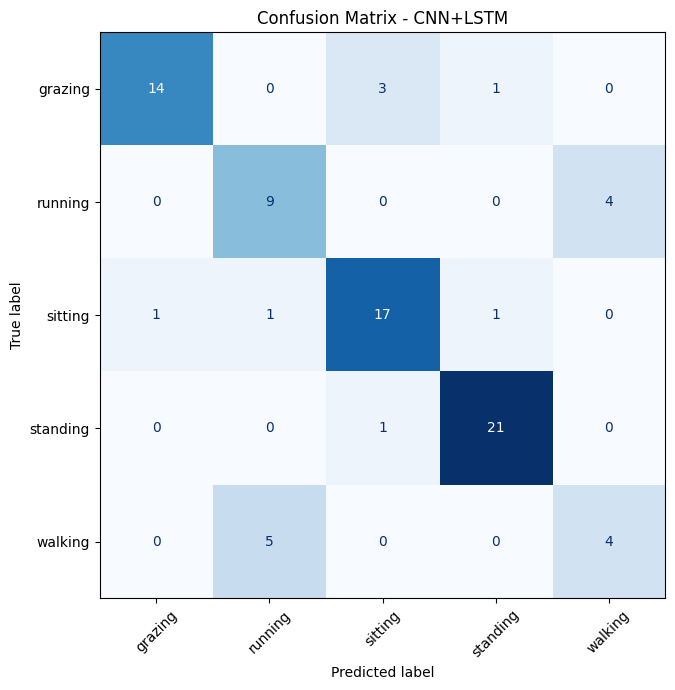

In [8]:
# ============================================================
# TEST EVALUATION
# ============================================================
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "cnn_lstm_best.pth")))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for frames, labels in test_loader:
        frames, labels = frames.to(device), labels.to(device)
        out = model(frames)
        preds = out.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
report   = classification_report(all_labels, all_preds, target_names=CLASS_NAMES)
cm       = confusion_matrix(all_labels, all_preds)

print(f"Test Accuracy: {test_acc:.4f}\n")
print("Classification Report:")
print(report)

with open(os.path.join(OUTPUT_DIR, "test_metrics.txt"), "w") as f:
    f.write(f"Test Accuracy: {test_acc:.4f}\n\n")
    f.write(report)

fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - CNN+LSTM")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

Comparison with other models

In [9]:
# ============================================================
# COMPARISON TABLE
# ============================================================
# fill in the actual numbers from tasks 2 and 3 after running
comparison = pd.DataFrame({
    "Model": ["2D CNN (1 frame)", "2D CNN (4 frame avg)", "3D CNN (8 frame clip)", "CNN+LSTM (8 frames)"],
    "Test Accuracy": ["~0.85", "~0.85", "~0.68", f"{test_acc:.4f}"],
    "Temporal Info": ["None", "None (averaged)", "Yes (3D conv)", "Yes (LSTM)"],
    "Trainable Params": ["~11M (full resnet)", "~11M (full resnet)", "~280K", f"{trainable:,}"]
})
print(comparison.to_string(index=False))

# CNN+LSTM should do better than 3D CNN because resnet features
# are much richer than what a small 3D CNN learns from scratch.
# compared to 2D CNN it should also help since LSTM captures ordering.

                Model Test Accuracy   Temporal Info   Trainable Params
     2D CNN (1 frame)         ~0.85            None ~11M (full resnet)
 2D CNN (4 frame avg)         ~0.85 None (averaged) ~11M (full resnet)
3D CNN (8 frame clip)         ~0.68   Yes (3D conv)              ~280K
  CNN+LSTM (8 frames)        0.7927      Yes (LSTM)            789,765
